In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import rasterio as rio
import pyvista as pv
from pyvista import examples
import os
import rasterio
import cmocean
import trame
import geopandas as gpd
import itertools
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

In [4]:
# Sets up interactibility in Pyvista displays
pv.set_jupyter_backend('trame')

In [5]:
# Reads GeoTIFF bathymetry file, change the file path as necessary. 
# If data accessed correctly, the file name should be the exact same.
dem = pv.read('south_polar_2025_4400000.0_-4400000.0_-4400000.0_4400000.0_geotiff.tif')
dem

ImageData (0x13bd5e40dc0)
  N Cells:      309724801
  N Points:     309760000
  X Bounds:     0.000e+00, 1.760e+04
  Y Bounds:     0.000e+00, 1.760e+04
  Z Bounds:     0.000e+00, 0.000e+00
  Dimensions:   17600, 17600, 1
  Spacing:      1.000e+00, 1.000e+00, 1.000e+00
  N Arrays:     1

In [6]:
# Reads GeoTIFF sub-ice bathymetry file, change the file path as necessary. 
# If data accessed correctly, the file name should be the exact same.
sub_ice = pv.read('south_polar_sub_ice_2025_4400000.0_-4400000.0_-4400000.0_4400000.0_geotiff.tif')
sub_ice

ImageData (0x13bd5e41960)
  N Cells:      309724801
  N Points:     309760000
  X Bounds:     0.000e+00, 1.760e+04
  Y Bounds:     0.000e+00, 1.760e+04
  Z Bounds:     0.000e+00, 0.000e+00
  Dimensions:   17600, 17600, 1
  Spacing:      1.000e+00, 1.000e+00, 1.000e+00
  N Arrays:     1

In [7]:
# Polar stereographic coordinates for visually-appealing graphic in Ronne Ice Shelf
xminpolar = -900000
xmaxpolar = -80000
yminpolar = 600000
ymaxpolar = 1400000

In [41]:
# Polar stereographic coordinates for Scott Glacier CSV

# NOTE: Run only if using Scott Glacier, change values if another region is used
xminpolar = -255250
xmaxpolar = -141750
yminpolar = -480250
ymaxpolar = -260250

In [42]:
# Retrieves the grounding line for Antarctica and clips it to the specified region
grounding_line = gpd.read_file('moa2014_grounding_line_v01.shp')
grounding_clip = grounding_line.clip_by_rect(xminpolar, yminpolar, xmaxpolar, ymaxpolar)

<Axes: >

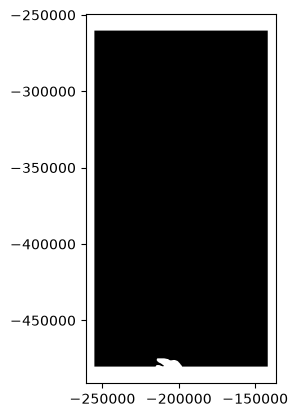

In [43]:
# Graphs the clipped grounding line
# Currently is not used further, but ideally will be implimented
grounding_clip.plot(color='black')

In [44]:
# Converts the polar sterographic coordinates to the size of the DEM's bounds
xmin = int(xminpolar*2/1000 + 8800)
xmax = int(xmaxpolar*2/1000 + 8800)
ymin = int(yminpolar*2/1000 + 8800)
ymax = int(ymaxpolar*2/1000 + 8800)

In [45]:
# Extracts a subsection of the DEM based on the specified region, then resizes the subset to be equal to their actual measurements
subset_surf = dem.extract_subset((xmin, xmax, ymin, ymax, 0, 0), (5, 5, 1))
surf_resize = subset_surf.resize(bounds = (xminpolar, xmaxpolar, yminpolar, ymaxpolar, 0, 0))
surf_resize

ImageData (0x13cb62ee260)
  N Cells:      3960
  N Points:     4094
  X Bounds:     -2.552e+05, -1.418e+05
  Y Bounds:     -4.802e+05, -2.602e+05
  Z Bounds:     0.000e+00, 0.000e+00
  Dimensions:   46, 89, 1
  Spacing:      2.522e+03, 2.500e+03, 0.000e+00
  N Arrays:     1

In [46]:
# Extracts a subsection of the DEM based on the specified region, then resizes the subset to be equal to their actual measurements
subset_bed = sub_ice.extract_subset((xmin, xmax, ymin, ymax, 0, 0), (5, 5, 1))
bed_resize = subset_bed.resize(bounds = (xminpolar, xmaxpolar, yminpolar, ymaxpolar, 0, 0))
bed_resize

ImageData (0x13cb62ef3a0)
  N Cells:      3960
  N Points:     4094
  X Bounds:     -2.552e+05, -1.418e+05
  Y Bounds:     -4.802e+05, -2.602e+05
  Z Bounds:     0.000e+00, 0.000e+00
  Dimensions:   46, 89, 1
  Spacing:      2.522e+03, 2.500e+03, 0.000e+00
  N Arrays:     1

In [47]:
# Adds Z bounds to the DEM subset based on the elevation scalar. Do not change factor or else measurements will be innacurate.
terrain = surf_resize.warp_by_scalar(
    factor = 1,
)
terrain

StructuredGrid (0x13c36ebd9c0)
  N Cells:      3960
  N Points:     4094
  X Bounds:     -2.552e+05, -1.418e+05
  Y Bounds:     -4.802e+05, -2.602e+05
  Z Bounds:     5.000e+00, 3.788e+03
  Dimensions:   46, 89, 1
  N Arrays:     1

In [48]:
# Adds Z bounds to the DEM subset based on the elevation scalar. Do not change factor or else measurements will be innacurate.
terrain_bed = bed_resize.warp_by_scalar(
    factor = 1,
)
terrain_bed

StructuredGrid (0x13c36ebda80)
  N Cells:      3960
  N Points:     4094
  X Bounds:     -2.552e+05, -1.418e+05
  Y Bounds:     -4.802e+05, -2.602e+05
  Z Bounds:     -1.448e+03, 3.780e+03
  Dimensions:   46, 89, 1
  N Arrays:     1

In [49]:
# Plots the bathymetry
terrain.plot(cmap = 'ice')

Widget(value='<iframe src="http://localhost:56317/index.html?ui=P_0x13c36f3dbb0_13&reconnect=auto" class="pyvi…

In [50]:
# Plots the sub-ice, or bed, bathymetry
terrain_bed.plot(cmap = 'ice')

Widget(value='<iframe src="http://localhost:56317/index.html?ui=P_0x13cb6103440_14&reconnect=auto" class="pyvi…

In [51]:
# Code block converts each DEM subset to a mesh with the Z bound scalar 'Elevation (m)'.

z_cells = np.array([100, 100])

xx_terrain = np.repeat(terrain.x, len(z_cells), axis=-1)
yy_terrain = np.repeat(terrain.y, len(z_cells), axis=-1)
zz_terrain = np.repeat(terrain.z, len(z_cells), axis=-1)

mesh_terrain = pv.StructuredGrid(xx_terrain, yy_terrain, zz_terrain)
mesh_terrain['Elevation (m)'] = zz_terrain.ravel(order='F')
mesh_terrain

xx_terrain_bed = np.repeat(terrain_bed.x, len(z_cells), axis=-1)
yy_terrain_bed = np.repeat(terrain_bed.y, len(z_cells), axis=-1)
zz_terrain_bed = np.repeat(terrain_bed.z, len(z_cells), axis=-1)

mesh_bed = pv.StructuredGrid(xx_terrain_bed, yy_terrain_bed, zz_terrain_bed)
mesh_bed['Elevation (m)'] = zz_terrain_bed.ravel(order='F')
mesh_bed

StructuredGrid (0x13c007ffc40)
  N Cells:      3960
  N Points:     8188
  X Bounds:     -2.552e+05, -1.418e+05
  Y Bounds:     -4.802e+05, -2.602e+05
  Z Bounds:     -1.448e+03, 3.780e+03
  Dimensions:   46, 89, 2
  N Arrays:     1

In [52]:
# Retrieves the maximum elevation value of the surface mesh. For camera position purposes only.
cmax = max(mesh_terrain['Elevation (m)'])

In [53]:
# Sets camera position for final plot based on polar coordinates, will require minor adjustments depending on study region.
cpos = pv.CameraPosition(

    # To change camera position, change the scalar each polar coordinate is multiplied by, make them negative for different viewing angles.
    # Change cmax exponent depending on region elevation, should be smaller for high elevation regions and visa versa.
    position=(xminpolar*2, yminpolar*4, cmax**1.85),

    # Change focal point of plot. Currently set to middle.
    focal_point=((xminpolar+xmaxpolar)/2, (yminpolar+ymaxpolar)/2, 0),

    # Change at your own risk. Changes vertical orientation to combination of x, y, or z axis.
    viewup=(0, 0, 1),
)

In [54]:
pl = pv.Plotter()

pl.add_title(title = 'GEBCO Bed and Surface Elevation')

# Change 'zscale' to stretch or squash vertical exaggeration. 'zscale' should be smaller for higher elevation regions and visa versa
pl.set_scale(zscale = 20)

# Change color or opacity of surface mesh to make comparison more or less visible.
pl.add_mesh(mesh_terrain, smooth_shading=True, color = 'white', opacity = 0.4)
pl.add_mesh(mesh_bed, smooth_shading=True, cmap = 'ice', scalars = 'Elevation (m)')
pl.show_grid(show_zaxis = False, show_zlabels = False, xtitle = 'X [km]', ytitle = 'Y [km]', font_size = 10)
pl.add_north_arrow_widget()
pl.add_text('N', color = 'black', position = 'lower_left', font_size = 15)
pl.camera_position = cpos
pl.show()

Widget(value='<iframe src="http://localhost:56317/index.html?ui=P_0x13c36f3eb40_15&reconnect=auto" class="pyvi…

## For DEMOGORN or other Bed Iterations ##

The following section is if there is a bed other than the GEBCO 2025 South Polar data set that is to be graphed. It can be skipped if not. An example bed and csv of Scott Glacier is provided in the documentation.

In [69]:
# Read region CSV, change file path as appropriate.
# NOTE: ensure region polar sterographic coordinate minumum and maximum are the same as xminpolar, xmaxpolar, yminpolar, and ymaxpolar
df = pd.read_csv('ScottDataGridded.csv')

In [56]:
# Extracts CSV xx and yy coordinates
x_uniq = np.unique(df.x)
y_uniq = np.unique(df.y)

xmin = np.min(x_uniq)
xmax = np.max(x_uniq)
ymin = np.min(y_uniq)
ymax = np.max(y_uniq)

cols = len(x_uniq)
rows = len(y_uniq)

resolution = 500

xx, yy = np.meshgrid(x_uniq, y_uniq)

In [70]:
# Load bed iteration. Change file path as appropriate. For .txt use np.loadtxt() instead of np.load().
bed_realization = np.load('bed_10000k.npy')

# Load Bedmap_bed for region from the csv dataset.
bedmap_bed = df['bedmap_bed'].values.reshape(xx.shape)

In [72]:
# Creates structured grid mesh from bed data
grid = pv.StructuredGrid(xx, yy, bed_realization)
grid['Elevation (m)'] = bed_realization.ravel(order='F')
grid.plot(smooth_shading = 'True')

C:\Users\Milo\AppData\Local\Temp\ipykernel_22328\389877075.py:2: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  grid = pv.StructuredGrid(xx, yy, bed_realization)


Widget(value='<iframe src="http://localhost:56317/index.html?ui=P_0x13ce8d59910_22&reconnect=auto" class="pyvi…

In [73]:
# Exactly the same as the one before, just with some variables changed to better suit Scott Glacier.

# Sets camera position for final plot based on polar coordinates, will require minor adjustments depending on study region.
cpos2 = pv.CameraPosition(

    # To change camera position, change the scalar each polar coordinate is multiplied by, make them negative for different viewing angles.
    # Change cmax exponent depending on region elevation, should be smaller for high elevation regions and visa versa.
    position=(xminpolar*2, yminpolar*2, cmax**1.45),

    # Change focal point of plot. Currently set to middle.
    focal_point=((xminpolar+xmaxpolar)/2, (yminpolar+ymaxpolar)/2, 0),

    # Change at your own risk. Changes vertical orientation to combination of x, y, or z axis.
    viewup=(0, 0, 1),
)

In [74]:
pl = pv.Plotter()

pl.add_title(title = 'Scott Glacier Iteration Difference')

# Change 'zscale' to stretch or squash vertical exaggeration. 'zscale' should be smaller for higher elevation regions and visa versa
pl.set_scale(zscale = 10)

# Change color or opacity of surface mesh to make comparison more or less visible.
pl.add_mesh(mesh_terrain, smooth_shading=True, color = 'white', opacity = 0.4)
pl.add_mesh(grid, smooth_shading=True, cmap = 'ice', scalars = 'Elevation (m)')
pl.show_grid(show_zaxis = False, show_zlabels = False, xtitle = 'X [km]', ytitle = 'Y [km]', font_size = 10)
pl.add_north_arrow_widget()
pl.add_text('N', color = 'black', position = 'lower_left', font_size = 15)
pl.camera_position = cpos2
pl.show()

Widget(value='<iframe src="http://localhost:56317/index.html?ui=P_0x13cbc023d40_23&reconnect=auto" class="pyvi…

In [75]:
# Calculates the difference between Bedmap_bed and a given bed realization.
# Currently, only Bedmap_bed works as a basis for comparison. Will be fixed soon.
diff_bed = bedmap_bed - bed_realization

In [76]:
# Plots Bedmap_bed and bed realization difference
diff = pv.StructuredGrid(xx, yy, diff_bed)
diff['Difference (m)'] = diff_bed.ravel(order='F')
diff.plot(smooth_shading = 'True', cmap = 'bwr')

C:\Users\Milo\AppData\Local\Temp\ipykernel_22328\1817008060.py:2: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  diff = pv.StructuredGrid(xx, yy, diff_bed)


Widget(value='<iframe src="http://localhost:56317/index.html?ui=P_0x13ccc7a19d0_24&reconnect=auto" class="pyvi…

In [79]:
pl = pv.Plotter()

pl.add_title(title = 'Bedmap and Bed Realization Difference')

# Change 'zscale' to stretch or squash vertical exaggeration. 'zscale' should be smaller for higher elevation regions and visa versa
# Recommended to keep zscale at or near 1 for difference plot
pl.set_scale(zscale = 2)
pl.add_mesh(diff, smooth_shading=True, cmap = 'bwr', scalars = 'Difference (m)')
pl.show_grid(show_zaxis = False, show_zlabels = False, xtitle = 'X [km]', ytitle = 'Y [km]', font_size = 10)
pl.add_north_arrow_widget()
pl.add_text('N', color = 'black', position = 'lower_left', font_size = 15)
pl.show()

Widget(value='<iframe src="http://localhost:56317/index.html?ui=P_0x13d12b9d790_27&reconnect=auto" class="pyvi…